100%|██████████| 11.2k/11.2k [00:00<00:00, 13.5MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/mohammadtalib786/retail-sales-dataset/versions/1
['retail_sales_dataset.csv']

FIRST 5 ROWS
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Col

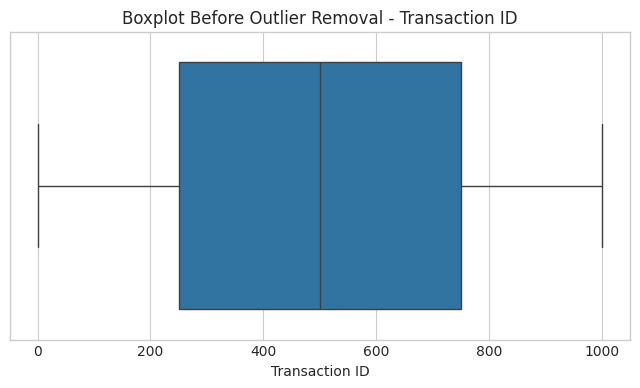


OUTLIERS REMOVED


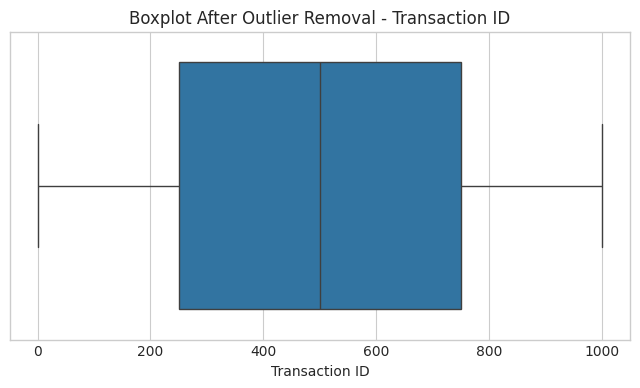

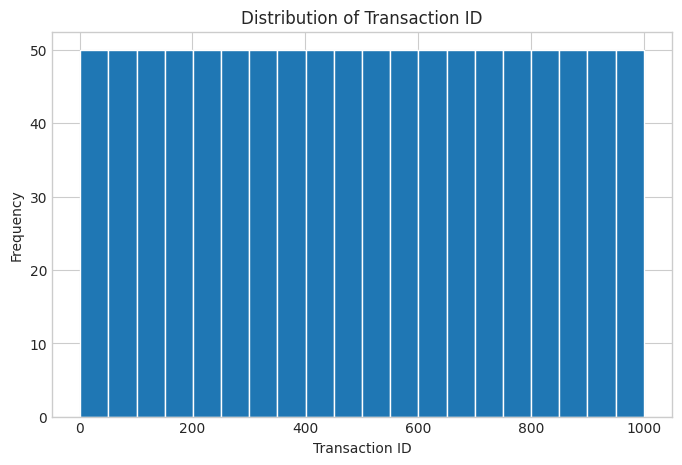

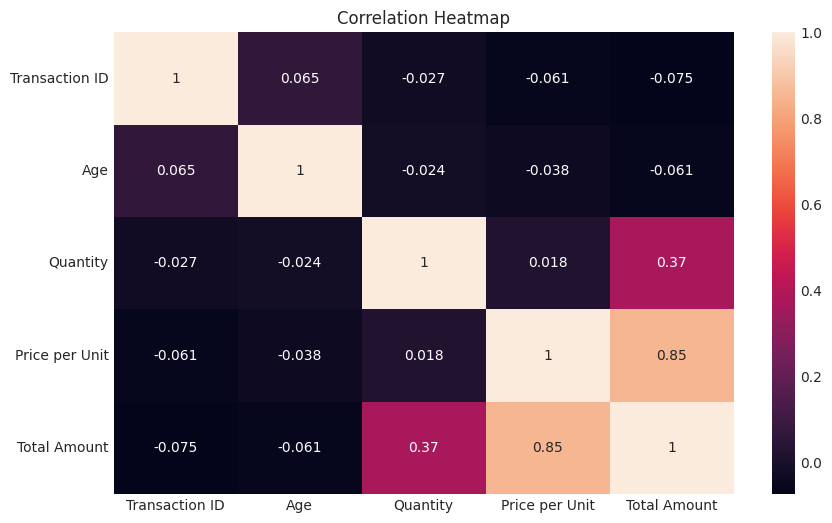

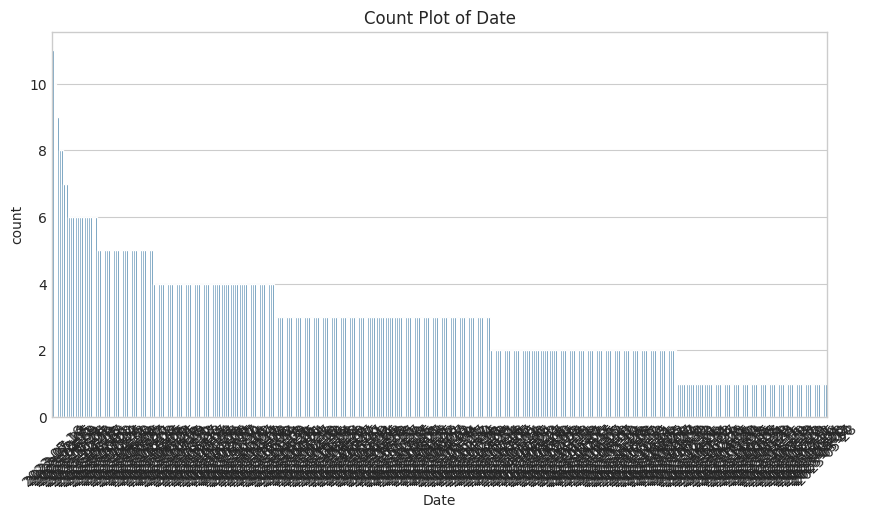

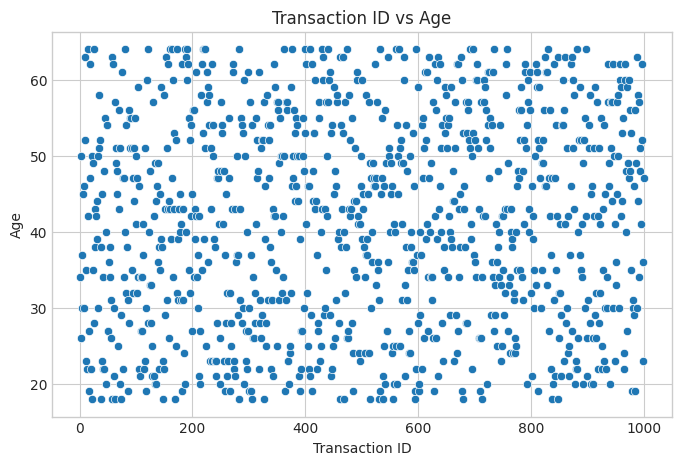

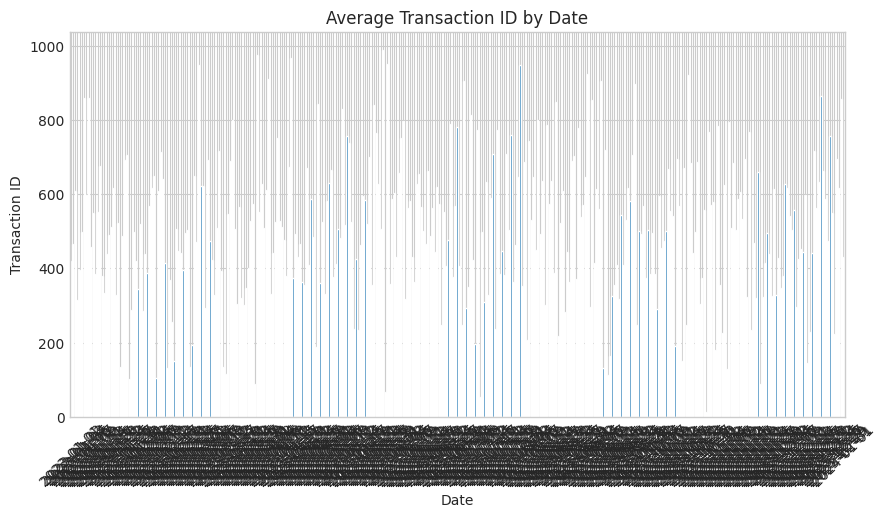


KEY FINDINGS / INSIGHTS

1. Dataset cleaned successfully
2. Missing values handled
3. Duplicate rows removed
4. Outliers removed using IQR method
5. Visualizations generated successfully
6. Correlation between numerical features analyzed


CLEANED DATASET SAVED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROJECT COMPLETED SUCCESSFULLY


In [2]:
# =========================================================
# RETAIL SALES DATA CLEANING & VISUALIZATION PROJECT
# Google Colab Runnable Code
# =========================================================

# -----------------------------
# STEP 1: INSTALL & IMPORT
# -----------------------------

!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
plt.rcParams['figure.figsize'] = (10,5)
sns.set_style("whitegrid")

# -----------------------------
# STEP 2: DOWNLOAD DATASET
# -----------------------------

path = kagglehub.dataset_download(
    "mohammadtalib786/retail-sales-dataset"
)

print("Dataset Path:", path)

# -----------------------------
# STEP 3: LOAD DATASET
# -----------------------------

import os

# Check files inside dataset folder
print(os.listdir(path))

# Replace filename if needed
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

# -----------------------------
# STEP 4: BASIC DATA ANALYSIS
# -----------------------------

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nSHAPE OF DATASET")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# -----------------------------
# STEP 5: CHECK MISSING VALUES
# -----------------------------

print("\nMISSING VALUES")
print(df.isnull().sum())

# -----------------------------
# STEP 6: HANDLE MISSING VALUES
# -----------------------------

# Fill numerical columns with median
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# -----------------------------
# STEP 7: REMOVE DUPLICATES
# -----------------------------

print("\nDUPLICATE ROWS:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("DUPLICATES REMOVED")

# -----------------------------
# STEP 8: CLEAN TEXT DATA
# -----------------------------

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nTEXT CLEANING COMPLETED")

# -----------------------------
# STEP 9: OUTLIER DETECTION
# -----------------------------

# Select one important numerical column
# Change column name if necessary

print("\nNUMERICAL COLUMNS:")
print(numerical_cols)

# Example target column
target_col = numerical_cols[0]

print("\nUSING COLUMN FOR OUTLIER DETECTION:", target_col)

# Boxplot before removing outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df[target_col])
plt.title(f'Boxplot Before Outlier Removal - {target_col}')
plt.show()

# IQR METHOD
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df = df[
    (df[target_col] >= lower_limit) &
    (df[target_col] <= upper_limit)
]

print("\nOUTLIERS REMOVED")

# Boxplot after removing outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df[target_col])
plt.title(f'Boxplot After Outlier Removal - {target_col}')
plt.show()

# -----------------------------
# STEP 10: DATA VISUALIZATION
# -----------------------------

# =====================================================
# DASHBOARD STYLE VISUAL REPORTS
# =====================================================

# ---------- HISTOGRAM ----------

plt.figure(figsize=(8,5))
plt.hist(df[target_col], bins=20)
plt.title(f'Distribution of {target_col}')
plt.xlabel(target_col)
plt.ylabel('Frequency')
plt.show()

# ---------- CORRELATION HEATMAP ----------

plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

# ---------- COUNT PLOT ----------

if len(categorical_cols) > 0:

    cat_col = categorical_cols[0]

    plt.figure(figsize=(10,5))

    sns.countplot(
        x=df[cat_col],
        order=df[cat_col].value_counts().index
    )

    plt.title(f'Count Plot of {cat_col}')
    plt.xticks(rotation=45)

    plt.show()

# ---------- SCATTER PLOT ----------

if len(numerical_cols) >= 2:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x=df[numerical_cols[0]],
        y=df[numerical_cols[1]]
    )

    plt.title(
        f'{numerical_cols[0]} vs {numerical_cols[1]}'
    )

    plt.show()

# ---------- BAR CHART ----------

if len(categorical_cols) > 0 and len(numerical_cols) > 0:

    group_data = df.groupby(cat_col)[target_col].mean()

    plt.figure(figsize=(10,5))

    group_data.plot(kind='bar')

    plt.title(f'Average {target_col} by {cat_col}')

    plt.ylabel(target_col)

    plt.xticks(rotation=45)

    plt.show()

# -----------------------------
# STEP 11: INSIGHTS
# -----------------------------

print("\n==============================")
print("KEY FINDINGS / INSIGHTS")
print("==============================")

print(f"""
1. Dataset cleaned successfully
2. Missing values handled
3. Duplicate rows removed
4. Outliers removed using IQR method
5. Visualizations generated successfully
6. Correlation between numerical features analyzed
""")

# -----------------------------
# STEP 12: SAVE CLEANED DATA
# -----------------------------

cleaned_file = "cleaned_retail_sales.csv"

df.to_csv(cleaned_file, index=False)

print("\nCLEANED DATASET SAVED")

# -----------------------------
# STEP 13: DOWNLOAD CLEANED FILE
# -----------------------------

from google.colab import files

files.download(cleaned_file)

print("\nPROJECT COMPLETED SUCCESSFULLY")